# Notebook 05 – Model Tuning and Final Model

## Part A – Shared Tuning Setup and Random Forest

This notebook performs hyperparameter tuning for the selected candidate models using the approved preprocessing pipeline and a fixed train/validation/test split.

### Part A Objectives
- Recreate the shared dataset and split from Notebook 04.
- Load and verify the Notebook 04 handoff reports.
- Define the shared 5-fold stratified cross-validation setup.
- Tune the Random Forest classifier using RandomizedSearchCV.
- Evaluate all sampled Random Forest configurations.
- Analyze cross-validation performance and overfitting.
- Evaluate the tuned Random Forest on the validation set.
- Export the Random Forest tuning results for the team handoff.

The reserved test set is not used during this tuning stage.

In [7]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

# Find the project root and add it to Python's import path
ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.preprocessing import PREDICTIVE_FEATURES, build_preprocessor

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

print("Project root:", ROOT)
print("src import: OK")

Project root: /Users/paveepiru/Desktop/Obesity-Risk-Intelligence-System
src import: OK


In [8]:
DATA = ROOT / "data"
REPORTS = ROOT / "reports" / "generated"

SEED = 42
TARGET = "NObeyesdad"

CLASSES = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

print("ROOT:", ROOT)
print("DATA:", DATA)
print("REPORTS:", REPORTS)
print("SEED:", SEED)
print("TARGET:", TARGET)

ROOT: /Users/paveepiru/Desktop/Obesity-Risk-Intelligence-System
DATA: /Users/paveepiru/Desktop/Obesity-Risk-Intelligence-System/data
REPORTS: /Users/paveepiru/Desktop/Obesity-Risk-Intelligence-System/reports/generated
SEED: 42
TARGET: NObeyesdad


## 1. Load and verify the dataset

The approved dataset contains 20,758 labelled observations and 18 columns:

- `id`
- 16 approved predictive features
- `NObeyesdad` as the seven-class target

The `id` column is excluded from modelling, and BMI is not included in the approved predictor set.

In [9]:
frame = pd.read_csv(DATA / "raw" / "obesity.csv")

print("Shape:", frame.shape)
print("Columns:")
print(frame.columns.tolist())

Shape: (20758, 18)
Columns:
['id', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


In [10]:
X = frame[list(PREDICTIVE_FEATURES)].copy()
y = frame[TARGET].copy()

assert X.shape == (20758, 16)
assert y.nunique() == 7

assert "id" not in X.columns
assert "BMI" not in X.columns

assert list(y.unique())  # confirms target exists

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of predictors:", X.shape[1])
print("Number of classes:", y.nunique())
print("\nClasses:")
print(sorted(y.unique()))

X shape: (20758, 16)
y shape: (20758,)
Number of predictors: 16
Number of classes: 7

Classes:
['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


## 2. Recreate the fixed train/validation/test split

The same two-stage stratified split from Notebook 04 is reproduced using random seed 42.

The resulting partitions are:

- Training: 14,530 observations
- Validation: 3,114 observations
- Reserved test: 3,114 observations

Stratification is used to preserve the seven-class distribution across the partitions.

The test set remains untouched during hyperparameter tuning.

In [11]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.50,
    stratify=y_tmp,
    random_state=SEED,
)

assert (len(X_train), len(X_val), len(X_test)) == (
    14530,
    3114,
    3114,
)

assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("No index overlap: PASS")

Train: (14530, 16)
Validation: (3114, 16)
Test: (3114, 16)
No index overlap: PASS


## 3. Shared evaluation metrics

Four metrics are used throughout the model comparison:

- Accuracy
- Balanced Accuracy
- Macro F1
- Weighted F1

Macro F1 is used as the primary model-selection metric during hyperparameter tuning because it gives equal importance to all seven classes.

In [12]:
def scores(name, actual, predicted):
    return {
        "Model": name,
        "Accuracy": accuracy_score(actual, predicted),
        "Balanced Accuracy": balanced_accuracy_score(actual, predicted),
        "Macro F1": f1_score(
            actual,
            predicted,
            average="macro",
            zero_division=0,
        ),
        "Weighted F1": f1_score(
            actual,
            predicted,
            average="weighted",
            zero_division=0,
        ),
    }

## 4. Verify the Notebook 04 handoff

Notebook 04 produced two reports:

1. `baseline_model_comparison.csv`
2. `tuning_candidates.csv`

The first contains the five baseline models, while the second identifies the two models selected for hyperparameter tuning.

In [13]:
baseline_report = pd.read_csv(
    REPORTS / "baseline_model_comparison.csv"
)

candidate_report = pd.read_csv(
    REPORTS / "tuning_candidates.csv"
)

assert len(baseline_report) == 5
assert len(candidate_report) == 2

assert set(candidate_report["Model"]) == {
    "Random Forest",
    "Gradient Boosting",
}

print("Baseline report:")
display(baseline_report)

print("\nTuning candidates:")
display(candidate_report)

Baseline report:


,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro F1 Rank,Balanced Accuracy Rank,Accuracy Rank
0,Gradient Boosting,0.903340,0.893142,0.893031,0.902952,1,1,1
1,Random Forest,0.895633,0.884543,0.884858,0.895254,2,2,2
2,Logistic Regression,0.858060,0.843242,0.841809,0.856599,3,3,3
3,Decision Tree,0.845215,0.831168,0.830801,0.845645,4,4,4
4,Dummy Classifier,0.194926,0.142857,0.046608,0.063596,5,5,5



Tuning candidates:


,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Training Macro F1,Macro F1 Gap
0,Gradient Boosting,0.903340,0.893142,0.893031,0.902952,0.912625,0.019594
1,Random Forest,0.895633,0.884543,0.884858,0.895254,1.000000,0.115142


## 5. Shared five-fold cross-validation setup

A five-fold StratifiedKFold strategy is used for hyperparameter tuning.

The same configuration must be reused for both Random Forest and Gradient Boosting so that the two tuning processes remain directly comparable.

For each model, 20 hyperparameter configurations are sampled and evaluated across five folds, resulting in 100 cross-validation fits per model.

In [14]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

SCORING = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
}

SEARCH_CONFIG = dict(
    n_iter=20,
    scoring=SCORING,
    refit="macro_f1",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

print("CV:", cv)
print("Search configuration:")
print(SEARCH_CONFIG)

CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
Search configuration:
{'n_iter': 20, 'scoring': {'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'macro_f1': 'f1_macro', 'weighted_f1': 'f1_weighted'}, 'refit': 'macro_f1', 'cv': StratifiedKFold(n_splits=5, random_state=42, shuffle=True), 'random_state': 42, 'n_jobs': -1, 'verbose': 1, 'return_train_score': True}


## 6. Random Forest hyperparameter search space

The Random Forest search explores six hyperparameters:

- `n_estimators`: number of trees
- `max_depth`: maximum tree depth
- `min_samples_split`: minimum samples required to split an internal node
- `min_samples_leaf`: minimum samples required in a leaf
- `max_features`: number of features considered when finding a split
- `class_weight`: optional class balancing strategy

RandomizedSearchCV samples 20 combinations from this search space rather than exhaustively evaluating every possible combination.

In [15]:
rf_params = {
    "classifier__n_estimators": [150, 200, 300, 400],
    "classifier__max_depth": [None, 10, 15, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2", 0.5],
    "classifier__class_weight": [
        None,
        "balanced",
        "balanced_subsample",
    ],
}

print("Random Forest hyperparameters:")

for parameter, values in rf_params.items():
    print(f"{parameter}: {values}")

Random Forest hyperparameters:
classifier__n_estimators: [150, 200, 300, 400]
classifier__max_depth: [None, 10, 15, 20, 30]
classifier__min_samples_split: [2, 5, 10]
classifier__min_samples_leaf: [1, 2, 4]
classifier__max_features: ['sqrt', 'log2', 0.5]
classifier__class_weight: [None, 'balanced', 'balanced_subsample']


## 7. Build the Random Forest pipeline

The approved preprocessing pipeline is placed directly inside the model pipeline.

This ensures that preprocessing is learned only from the training folds during cross-validation, preventing preprocessing leakage.

The Random Forest uses `n_jobs=1` because the outer RandomizedSearchCV already uses parallel processing with `n_jobs=-1`.

In [16]:
rf_pipe = Pipeline([
    (
        "preprocessor",
        build_preprocessor(),
    ),
    (
        "classifier",
        RandomForestClassifier(
            random_state=SEED,
            n_jobs=1,
        ),
    ),
])

print(rf_pipe)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
              

## 8. Random Forest hyperparameter tuning

RandomizedSearchCV is fitted using only the training partition.

The validation and test partitions are not used during the search.

The model is selected using cross-validated Macro F1, while Accuracy, Balanced Accuracy, and Weighted F1 are also recorded.

In [17]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_params,
    **SEARCH_CONFIG,
)

rf_search.fit(X_train, y_train)

print("\nBest CV Macro F1:", rf_search.best_score_)

print("\nBest parameters:")
for parameter, value in rf_search.best_params_.items():
    print(f"{parameter}: {value}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV Macro F1: 0.8875347456357963

Best parameters:
classifier__n_estimators: 150
classifier__min_samples_split: 10
classifier__min_samples_leaf: 2
classifier__max_features: 0.5
classifier__max_depth: 20
classifier__class_weight: None


In [18]:
print("Search completed.")
print("Number of candidates evaluated:", len(rf_search.cv_results_))
print("Best CV Macro F1:", rf_search.best_score_)
print(
    "Best estimator:",
    type(rf_search.best_estimator_).__name__,
)

Search completed.
Number of candidates evaluated: 71
Best CV Macro F1: 0.8875347456357963
Best estimator: Pipeline


## 9. Inspect Random Forest cross-validation results

All 20 sampled configurations are retained for analysis.

The cross-validation Macro F1 gap is calculated as:

Training Macro F1 − Validation Fold Macro F1

A larger positive gap can indicate that a configuration fits the training folds substantially better than unseen validation folds, which may indicate overfitting.

In [19]:
rf_full = pd.DataFrame(rf_search.cv_results_)

rf_full["CV Macro F1 Gap"] = (
    rf_full["mean_train_macro_f1"]
    - rf_full["mean_test_macro_f1"]
)

display(
    rf_full.sort_values("rank_test_macro_f1")[
        [
            "rank_test_macro_f1",
            "mean_test_macro_f1",
            "std_test_macro_f1",
            "mean_train_macro_f1",
            "CV Macro F1 Gap",
        ]
    ].head(10)
)

,rank_test_macro_f1,mean_test_macro_f1,std_test_macro_f1,mean_train_macro_f1,CV Macro F1 Gap
16,1,0.887535,0.005917,0.945094,0.057559
19,2,0.887075,0.004960,0.990793,0.103718
4,3,0.886550,0.006461,0.985094,0.098544
5,4,0.886535,0.007270,0.974127,0.087592
11,5,0.885989,0.006998,0.964490,0.078501
10,6,0.885527,0.007059,0.959839,0.074312
6,7,0.884884,0.006269,0.984635,0.099751
15,8,0.882925,0.007448,0.988683,0.105757
14,9,0.882574,0.006307,0.974941,0.092367
3,10,0.881110,0.005831,0.939971,0.058861


## 10. Validation evaluation of the tuned Random Forest

The best Random Forest found through cross-validation is now evaluated on the separate validation partition.

This validation result is compared with the original Notebook 04 Random Forest baseline.

The reserved test set is still not evaluated in Part A.

In [20]:
rf_val = scores(
    "Random Forest",
    y_val,
    rf_search.best_estimator_.predict(X_val),
)

base_rf = baseline_report.set_index("Model").loc[
    "Random Forest",
    "Macro F1",
]

print("Baseline RF Macro F1:", base_rf)
print("Tuned RF Macro F1:", rf_val["Macro F1"])
print("Change:", rf_val["Macro F1"] - base_rf)

print("\nTuned Random Forest validation metrics:")
display(pd.DataFrame([rf_val]))

Baseline RF Macro F1: 0.8848580437360324
Tuned RF Macro F1: 0.8956219303904118
Change: 0.01076388665437944

Tuned Random Forest validation metrics:


,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
0,Random Forest,0.904945,0.895591,0.895622,0.904677


## 11. Export Random Forest tuning results

The complete results from all 20 sampled Random Forest configurations are exported to:

`reports/generated/random_forest_tuning_results.csv`

The exported report contains the ranking, cross-validation metrics, training Macro F1, fit time, and all six Random Forest hyperparameters.

In [21]:
cv_cols = [
    "rank_test_macro_f1",
    "mean_test_macro_f1",
    "std_test_macro_f1",
    "mean_train_macro_f1",
    "mean_test_accuracy",
    "mean_test_balanced_accuracy",
    "mean_test_weighted_f1",
    "mean_fit_time",
]

rf_cols = cv_cols + [
    "param_" + parameter
    for parameter in rf_params
]

rf_report = rf_full.sort_values(
    "rank_test_macro_f1"
)[rf_cols]

rf_report.to_csv(
    REPORTS / "random_forest_tuning_results.csv",
    index=False,
)

assert len(rf_report) == 20

print(
    "Saved:",
    REPORTS / "random_forest_tuning_results.csv",
)

print("Rows exported:", len(rf_report))
print("Columns exported:", len(rf_report.columns))

display(rf_report.head())

Saved: /Users/paveepiru/Desktop/Obesity-Risk-Intelligence-System/reports/generated/random_forest_tuning_results.csv
Rows exported: 20
Columns exported: 14


,rank_test_macro_f1,mean_test_macro_f1,std_test_macro_f1,mean_train_macro_f1,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_weighted_f1,mean_fit_time,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_split,param_classifier__min_samples_leaf,param_classifier__max_features,param_classifier__class_weight
16,1,0.887535,0.005917,0.945094,0.898624,0.887359,0.898396,3.007943,150,20,10,2,0.5,NaN
19,2,0.887075,0.004960,0.990793,0.898211,0.886852,0.897944,3.114045,200,15,2,1,0.5,NaN
4,3,0.886550,0.006461,0.985094,0.897591,0.886542,0.897438,6.473355,300,30,5,1,0.5,balanced_subsample
5,4,0.886535,0.007270,0.974127,0.897522,0.886608,0.897393,4.293173,200,None,2,2,0.5,balanced_subsample
11,5,0.885989,0.006998,0.964490,0.896972,0.886322,0.896918,3.016217,150,15,5,2,0.5,balanced


## 12. Part A completion checks

The following checks confirm that the Random Forest tuning workflow completed successfully.

- The shared split remains unchanged.
- Exactly 20 Random Forest configurations were evaluated.
- Macro F1 was used for model selection.
- The validation set was used only after tuning.
- The test set was not used for tuning or validation comparison.
- The complete Random Forest tuning report was exported.

In [22]:
assert len(rf_search.cv_results_["params"]) == 20
assert rf_search.refit == "macro_f1"
assert len(rf_report) == 20
assert set(rf_report.columns) == set(rf_cols)

assert len(X_train) == 14530
assert len(X_val) == 3114
assert len(X_test) == 3114

print("20 RF configurations: PASS")
print("Macro F1 refit: PASS")
print("RF tuning report: PASS")
print("Train/validation/test split: PASS")
print("Part A Random Forest tuning workflow: COMPLETE")

20 RF configurations: PASS
Macro F1 refit: PASS
RF tuning report: PASS
Train/validation/test split: PASS
Part A Random Forest tuning workflow: COMPLETE


## 13. Part A handoff to Part B

### Random Forest objects retained in the notebook

The following objects contain the Random Forest tuning results:

- `rf_search` – fitted RandomizedSearchCV object
- `rf_full` – complete 20-configuration CV results
- `rf_val` – tuned Random Forest validation metrics
- `rf_report` – exported Random Forest tuning report
- `SEARCH_CONFIG` – shared search configuration
- `cv` – shared StratifiedKFold configuration

### Exported report

`reports/generated/random_forest_tuning_results.csv`

Part B can use the same shared data split, scoring configuration, and search configuration for Gradient Boosting.

The reserved test set remains untouched until the joint final-model review.

## 14. Final Random Forest tuning summary

The Random Forest hyperparameter search evaluated 20 sampled configurations using five-fold stratified cross-validation.

The best configuration was selected using cross-validated Macro F1. The selected model was then evaluated on the separate validation partition and compared against the Notebook 04 Random Forest baseline.

The reserved test partition was not used during this tuning stage.

In [23]:
print("===== RANDOM FOREST TUNING SUMMARY =====")

print(f"Best CV Macro F1: {rf_search.best_score_:.6f}")

print("\nBest parameters:")
for parameter, value in rf_search.best_params_.items():
    print(f"  {parameter}: {value}")

print("\nValidation metrics:")
for metric, value in rf_val.items():
    if metric != "Model":
        print(f"  {metric}: {value:.6f}")

print("\nBaseline RF Macro F1:", f"{base_rf:.6f}")
print("Tuned RF Macro F1:", f"{rf_val['Macro F1']:.6f}")
print(
    "Validation Macro F1 change:",
    f"{rf_val['Macro F1'] - base_rf:+.6f}"
)

===== RANDOM FOREST TUNING SUMMARY =====
Best CV Macro F1: 0.887535

Best parameters:
  classifier__n_estimators: 150
  classifier__min_samples_split: 10
  classifier__min_samples_leaf: 2
  classifier__max_features: 0.5
  classifier__max_depth: 20
  classifier__class_weight: None

Validation metrics:
  Accuracy: 0.904945
  Balanced Accuracy: 0.895591
  Macro F1: 0.895622
  Weighted F1: 0.904677

Baseline RF Macro F1: 0.884858
Tuned RF Macro F1: 0.895622
Validation Macro F1 change: +0.010764


## 15. Random Forest cross-validation performance

The table below shows the strongest Random Forest configurations according to cross-validated Macro F1.

The training-validation Macro F1 gap is retained to help identify configurations that may show signs of overfitting.

In [24]:
top_rf = rf_full.sort_values(
    "rank_test_macro_f1"
).copy()

top_rf[
    [
        "rank_test_macro_f1",
        "mean_test_macro_f1",
        "std_test_macro_f1",
        "mean_train_macro_f1",
        "CV Macro F1 Gap",
    ]
].head(10)

,rank_test_macro_f1,mean_test_macro_f1,std_test_macro_f1,mean_train_macro_f1,CV Macro F1 Gap
16,1,0.887535,0.005917,0.945094,0.057559
19,2,0.887075,0.004960,0.990793,0.103718
4,3,0.886550,0.006461,0.985094,0.098544
5,4,0.886535,0.007270,0.974127,0.087592
11,5,0.885989,0.006998,0.964490,0.078501
10,6,0.885527,0.007059,0.959839,0.074312
6,7,0.884884,0.006269,0.984635,0.099751
15,8,0.882925,0.007448,0.988683,0.105757
14,9,0.882574,0.006307,0.974941,0.092367
3,10,0.881110,0.005831,0.939971,0.058861


## 16. Export verification

The Random Forest tuning report contains the 20 sampled configurations and the required cross-validation results and hyperparameters.

In [25]:
rf_output = REPORTS / "random_forest_tuning_results.csv"

assert rf_output.exists()

saved_rf_report = pd.read_csv(rf_output)

assert len(saved_rf_report) == 20
assert len(saved_rf_report.columns) == 14

print("File exists:", rf_output.exists())
print("Rows:", len(saved_rf_report))
print("Columns:", len(saved_rf_report.columns))

display(saved_rf_report.head())

File exists: True
Rows: 20
Columns: 14


,rank_test_macro_f1,mean_test_macro_f1,std_test_macro_f1,mean_train_macro_f1,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_weighted_f1,mean_fit_time,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_split,param_classifier__min_samples_leaf,param_classifier__max_features,param_classifier__class_weight
0,1,0.887535,0.005917,0.945094,0.898624,0.887359,0.898396,3.007943,150,20.0,10,2,0.5,NaN
1,2,0.887075,0.004960,0.990793,0.898211,0.886852,0.897944,3.114045,200,15.0,2,1,0.5,NaN
2,3,0.886550,0.006461,0.985094,0.897591,0.886542,0.897438,6.473355,300,30.0,5,1,0.5,balanced_subsample
3,4,0.886535,0.007270,0.974127,0.897522,0.886608,0.897393,4.293173,200,NaN,2,2,0.5,balanced_subsample
4,5,0.885989,0.006998,0.964490,0.896972,0.886322,0.896918,3.016217,150,15.0,5,2,0.5,balanced


## Part B — Gradient Boosting Hyperparameter Tuning

Gradient Boosting is tuned using RandomizedSearchCV with 20 randomly sampled hyperparameter configurations and 5-fold stratified cross-validation.

The same evaluation metrics are used as the Random Forest tuning:
- Accuracy
- Balanced Accuracy
- Macro F1
- Weighted F1

Macro F1 is used as the primary metric for model selection.

In [26]:
import sys
print(sys.executable)

import sklearn
print(sklearn.__version__)

/Users/paveepiru/Desktop/Obesity-Risk-Intelligence-System/.venv/bin/python
1.9.1


In [27]:
from sklearn.ensemble import GradientBoostingClassifier

gb_params = {
    "classifier__n_estimators": [75, 100, 150, 200],
    "classifier__learning_rate": [0.03, 0.05, 0.10, 0.15],
    "classifier__max_depth": [2, 3, 4],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__subsample": [0.8, 0.9, 1.0],
    "classifier__max_features": [None, "sqrt", 0.8],
}

print("Gradient Boosting hyperparameters:")

for parameter, values in gb_params.items():
    print(f"{parameter}: {values}")

Gradient Boosting hyperparameters:
classifier__n_estimators: [75, 100, 150, 200]
classifier__learning_rate: [0.03, 0.05, 0.1, 0.15]
classifier__max_depth: [2, 3, 4]
classifier__min_samples_split: [2, 5, 10]
classifier__min_samples_leaf: [1, 2, 4]
classifier__subsample: [0.8, 0.9, 1.0]
classifier__max_features: [None, 'sqrt', 0.8]


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

gb_pipe = Pipeline([
    (
        "preprocessor",
        build_preprocessor(),
    ),
    (
        "classifier",
        GradientBoostingClassifier(
            random_state=SEED,
        ),
    ),
])

print(gb_pipe)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
              

### Gradient Boosting Randomized Search

RandomizedSearchCV is used to explore the Gradient Boosting hyperparameter space efficiently.

The search uses 20 candidate configurations and 5-fold stratified cross-validation. The model is refitted using the configuration with the highest cross-validation Macro F1 score.

In [38]:
gb_search = RandomizedSearchCV(
    estimator=gb_pipe,
    param_distributions=gb_params,
    **SEARCH_CONFIG,
)

gb_search.fit(X_train, y_train)

print("\nBest CV Macro F1:", gb_search.best_score_)

print("\nBest parameters:")
for parameter, value in gb_search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nNumber of candidates evaluated:", len(gb_search.cv_results_))


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV Macro F1: 0.8921790676308762

Best parameters:
classifier__subsample: 0.8
classifier__n_estimators: 100
classifier__min_samples_split: 5
classifier__min_samples_leaf: 2
classifier__max_features: 0.8
classifier__max_depth: 3
classifier__learning_rate: 0.15

Number of candidates evaluated: 72


### Gradient Boosting Tuning Results

The best Gradient Boosting configuration is identified based on the highest cross-validation Macro F1 score.

In [39]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

gb_val_pred = gb_search.best_estimator_.predict(X_val)

gb_val_accuracy = accuracy_score(y_val, gb_val_pred)
gb_val_balanced_accuracy = balanced_accuracy_score(y_val, gb_val_pred)
gb_val_macro_f1 = f1_score(y_val, gb_val_pred, average="macro")
gb_val_weighted_f1 = f1_score(y_val, gb_val_pred, average="weighted")

print("Tuned Gradient Boosting - Validation Results")
print(f"Accuracy:           {gb_val_accuracy:.6f}")
print(f"Balanced Accuracy:  {gb_val_balanced_accuracy:.6f}")
print(f"Macro F1:            {gb_val_macro_f1:.6f}")
print(f"Weighted F1:         {gb_val_weighted_f1:.6f}")

print("\nClassification Report:")
print(classification_report(y_val, gb_val_pred))

Tuned Gradient Boosting - Validation Results
Accuracy:           0.905267
Balanced Accuracy:  0.895508
Macro F1:            0.895436
Weighted F1:         0.904891

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.95      0.93       379
      Normal_Weight       0.89      0.89      0.89       463
     Obesity_Type_I       0.87      0.89      0.88       436
    Obesity_Type_II       0.95      0.96      0.96       487
   Obesity_Type_III       1.00      1.00      1.00       607
 Overweight_Level_I       0.83      0.77      0.80       364
Overweight_Level_II       0.82      0.82      0.82       378

           accuracy                           0.91      3114
          macro avg       0.90      0.90      0.90      3114
       weighted avg       0.90      0.91      0.90      3114



In [41]:
class_names = sorted(y_val.unique())

gb_val_cm = confusion_matrix(y_val, gb_val_pred)

print("Confusion Matrix:")

display(
    pd.DataFrame(
        gb_val_cm,
        index=class_names,
        columns=class_names,
    )
)

Confusion Matrix:


,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Insufficient_Weight,359,17,0,0,0,3,0
Normal_Weight,28,411,0,0,0,21,3
Obesity_Type_I,1,1,386,18,1,7,22
Obesity_Type_II,0,0,20,466,0,1,0
Obesity_Type_III,0,0,1,1,605,0,0
Overweight_Level_I,2,28,8,0,0,281,45
Overweight_Level_II,0,7,31,3,0,26,311


### Saving Gradient Boosting Tuning Results

The 20 evaluated Gradient Boosting configurations are saved as a CSV file for reproducibility and later comparison with the Random Forest tuning results.

In [42]:
gb_results = pd.DataFrame(gb_search.cv_results_)

gb_results = gb_results.sort_values(
    by="rank_test_macro_f1"
).reset_index(drop=True)

gb_results.to_csv(
    "../reports/generated/gradient_boosting_tuning_results.csv",
    index=False,
)

print("Saved:", "../reports/generated/gradient_boosting_tuning_results.csv")
print("Number of rows:", len(gb_results))

Saved: ../reports/generated/gradient_boosting_tuning_results.csv
Number of rows: 20


### Gradient Boosting Validation Evaluation

The tuned Gradient Boosting model is evaluated on the validation set using accuracy, balanced accuracy, Macro F1, and weighted F1.

A classification report and confusion matrix are used to examine performance across the seven obesity-risk classes.

In [44]:
# ============================================================
# Part B — Compare Baseline and Tuned Models
# ============================================================

# Tuned Gradient Boosting validation metrics
gb_tuned_metrics = {
    "Model": "Gradient Boosting - Tuned",
    "Accuracy": accuracy_score(y_val, gb_val_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_val, gb_val_pred),
    "Macro F1": f1_score(y_val, gb_val_pred, average="macro"),
    "Weighted F1": f1_score(y_val, gb_val_pred, average="weighted"),
}

print("Tuned Gradient Boosting:")
for metric, value in gb_tuned_metrics.items():
    if metric != "Model":
        print(f"{metric}: {value:.6f}")

Tuned Gradient Boosting:
Accuracy: 0.905267
Balanced Accuracy: 0.895508
Macro F1: 0.895436
Weighted F1: 0.904891


### Classification Report

In [46]:
print(
    classification_report(
        y_val,
        gb_val_pred,
        target_names=class_names,
        digits=2
    )
)

                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.95      0.93       379
      Normal_Weight       0.89      0.89      0.89       463
     Obesity_Type_I       0.87      0.89      0.88       436
    Obesity_Type_II       0.95      0.96      0.96       487
   Obesity_Type_III       1.00      1.00      1.00       607
 Overweight_Level_I       0.83      0.77      0.80       364
Overweight_Level_II       0.82      0.82      0.82       378

           accuracy                           0.91      3114
          macro avg       0.90      0.90      0.90      3114
       weighted avg       0.90      0.91      0.90      3114



### Confusion Matrix

In [47]:
gb_val_cm = confusion_matrix(
    y_val,
    gb_val_pred
)

display(
    pd.DataFrame(
        gb_val_cm,
        index=class_names,
        columns=class_names
    )
)

,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Insufficient_Weight,359,17,0,0,0,3,0
Normal_Weight,28,411,0,0,0,21,3
Obesity_Type_I,1,1,386,18,1,7,22
Obesity_Type_II,0,0,20,466,0,1,0
Obesity_Type_III,0,0,1,1,605,0,0
Overweight_Level_I,2,28,8,0,0,281,45
Overweight_Level_II,0,7,31,3,0,26,311


### Model Comparison — Baseline vs Tuned

The baseline and tuned Random Forest and Gradient Boosting models are compared using the validation set.

Macro F1 is used as the primary comparison metric, while accuracy, balanced accuracy, and weighted F1 are also considered.

The reserved test set is not used during model selection.

In [49]:
baseline_results = pd.read_csv(
    "../reports/generated/baseline_model_comparison.csv"
)

display(baseline_results)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro F1 Rank,Balanced Accuracy Rank,Accuracy Rank
0,Gradient Boosting,0.903340,0.893142,0.893031,0.902952,1,1,1
1,Random Forest,0.895633,0.884543,0.884858,0.895254,2,2,2
2,Logistic Regression,0.858060,0.843242,0.841809,0.856599,3,3,3
3,Decision Tree,0.845215,0.831168,0.830801,0.845645,4,4,4
4,Dummy Classifier,0.194926,0.142857,0.046608,0.063596,5,5,5


In [52]:
# Save Gradient Boosting tuned validation metrics

gb_val_metrics = {
    "Model": "Gradient Boosting - Tuned",
    "Accuracy": accuracy_score(y_val, gb_val_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_val, gb_val_pred),
    "Macro F1": f1_score(y_val, gb_val_pred, average="macro"),
    "Weighted F1": f1_score(y_val, gb_val_pred, average="weighted"),
}

print("Tuned Gradient Boosting:")
print(f"Accuracy: {gb_val_metrics['Accuracy']:.6f}")
print(f"Balanced Accuracy: {gb_val_metrics['Balanced Accuracy']:.6f}")
print(f"Macro F1: {gb_val_metrics['Macro F1']:.6f}")
print(f"Weighted F1: {gb_val_metrics['Weighted F1']:.6f}")

Tuned Gradient Boosting:
Accuracy: 0.905267
Balanced Accuracy: 0.895508
Macro F1: 0.895436
Weighted F1: 0.904891


In [53]:
# ============================================================
# Model Comparison — Baseline vs Tuned
# ============================================================

# Extract baseline model results
rf_baseline = baseline_results[
    baseline_results["Model"] == "Random Forest"
].iloc[0]

gb_baseline = baseline_results[
    baseline_results["Model"] == "Gradient Boosting"
].iloc[0]

# Create comparison table
comparison_results = pd.DataFrame([
    {
        "Model": "Random Forest - Baseline",
        "Accuracy": rf_baseline["Accuracy"],
        "Balanced Accuracy": rf_baseline["Balanced Accuracy"],
        "Macro F1": rf_baseline["Macro F1"],
        "Weighted F1": rf_baseline["Weighted F1"],
    },
    {
        "Model": "Random Forest - Tuned",
        "Accuracy": rf_tuned_metrics["Accuracy"],
        "Balanced Accuracy": rf_tuned_metrics["Balanced Accuracy"],
        "Macro F1": rf_tuned_metrics["Macro F1"],
        "Weighted F1": rf_tuned_metrics["Weighted F1"],
    },
    {
        "Model": "Gradient Boosting - Baseline",
        "Accuracy": gb_baseline["Accuracy"],
        "Balanced Accuracy": gb_baseline["Balanced Accuracy"],
        "Macro F1": gb_baseline["Macro F1"],
        "Weighted F1": gb_baseline["Weighted F1"],
    },
    {
        "Model": "Gradient Boosting - Tuned",
        "Accuracy": gb_val_metrics["Accuracy"],
        "Balanced Accuracy": gb_val_metrics["Balanced Accuracy"],
        "Macro F1": gb_val_metrics["Macro F1"],
        "Weighted F1": gb_val_metrics["Weighted F1"],
    },
])

# Sort by Macro F1
comparison_results = comparison_results.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

display(comparison_results)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
0,Random Forest - Tuned,0.904945,0.895591,0.895622,0.904677
1,Gradient Boosting - Tuned,0.905267,0.895508,0.895436,0.904891
2,Gradient Boosting - Baseline,0.903340,0.893142,0.893031,0.902952
3,Random Forest - Baseline,0.895633,0.884543,0.884858,0.895254


In [54]:
comparison_results.to_csv(
    "../reports/generated/model_tuning_comparison.csv",
    index=False
)

print(
    "Saved:",
    "../reports/generated/model_tuning_comparison.csv"
)

Saved: ../reports/generated/model_tuning_comparison.csv


## Leading Model Candidate

The leading model candidate is selected based on validation Macro F1.

The Random Forest tuned model achieved the highest validation Macro F1 among the four evaluated candidates.

The reserved test set is not used during model selection.

In [55]:
leading_model = comparison_results.iloc[0]

print("Leading Model Candidate")
print("-----------------------")
print(f"Model: {leading_model['Model']}")
print(f"Accuracy: {leading_model['Accuracy']:.6f}")
print(f"Balanced Accuracy: {leading_model['Balanced Accuracy']:.6f}")
print(f"Macro F1: {leading_model['Macro F1']:.6f}")
print(f"Weighted F1: {leading_model['Weighted F1']:.6f}")

Leading Model Candidate
-----------------------
Model: Random Forest - Tuned
Accuracy: 0.904945
Balanced Accuracy: 0.895591
Macro F1: 0.895622
Weighted F1: 0.904677


In [56]:
leading_model.to_frame().T.to_csv(
    "../reports/generated/leading_model_candidate.csv",
    index=False
)

print(
    "Saved:",
    "../reports/generated/leading_model_candidate.csv"
)

Saved: ../reports/generated/leading_model_candidate.csv


## Final Model Training

After selecting the leading model candidate using the validation set, the model is retrained using the combined training and validation datasets.

The reserved test set is used only for the final evaluation.

In [57]:
from sklearn.base import clone
import pandas as pd

# Combine training and validation data
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

print("Development set shape:", X_dev.shape)
print("Development target shape:", y_dev.shape)

# Create a fresh copy of the selected tuned Random Forest
final_model = clone(rf_search.best_estimator_)

# Train on combined training + validation data
final_model.fit(X_dev, y_dev)

print("Final Random Forest model trained successfully.")

Development set shape: (17644, 16)
Development target shape: (17644,)
Final Random Forest model trained successfully.


## Final Test Evaluation

The final selected model is evaluated once on the reserved test set.

The test set was not used during preprocessing decisions, hyperparameter tuning, or model selection. Therefore, these results provide the final estimate of model performance on unseen data.

In [58]:
# Final prediction on the reserved test set
final_test_pred = final_model.predict(X_test)

print("Final test prediction completed.")
print("Number of test samples:", len(final_test_pred))

Final test prediction completed.
Number of test samples: 3114


In [59]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

final_test_metrics = {
    "Model": "Random Forest - Tuned",
    "Accuracy": accuracy_score(y_test, final_test_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, final_test_pred),
    "Macro F1": f1_score(y_test, final_test_pred, average="macro"),
    "Weighted F1": f1_score(y_test, final_test_pred, average="weighted")
}

print("Final Test Metrics")
print("------------------")

for metric, value in final_test_metrics.items():
    if metric == "Model":
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.6f}")

Final Test Metrics
------------------
Model: Random Forest - Tuned
Accuracy: 0.902376
Balanced Accuracy: 0.892380
Macro F1: 0.891663
Weighted F1: 0.901950


### Saving Final Test Metrics

The final test metrics are saved for reproducibility and reporting.

In [60]:
final_test_metrics_df = pd.DataFrame([final_test_metrics])

final_test_metrics_df.to_csv(
    "../reports/generated/final_test_metrics.csv",
    index=False
)

print("Saved:", "../reports/generated/final_test_metrics.csv")

Saved: ../reports/generated/final_test_metrics.csv


### Final Classification Report

The classification report provides precision, recall, and F1-score for each obesity-risk class on the reserved test set.

In [61]:
from sklearn.metrics import classification_report

final_report = classification_report(
    y_test,
    final_test_pred,
    target_names=class_names,
    output_dict=True
)

final_report_df = pd.DataFrame(final_report).T

display(final_report_df)

,precision,recall,f1-score,support
Insufficient_Weight,0.902010,0.949735,0.925258,378.000000
Normal_Weight,0.867550,0.850649,0.859016,462.000000
Obesity_Type_I,0.914081,0.876430,0.894860,437.000000
Obesity_Type_II,0.965795,0.985626,0.975610,487.000000
Obesity_Type_III,0.996700,0.995058,0.995878,607.000000
Overweight_Level_I,0.796512,0.752747,0.774011,364.000000
Overweight_Level_II,0.798489,0.836412,0.817010,379.000000
accuracy,0.902376,0.902376,0.902376,0.902376
macro avg,0.891591,0.892380,0.891663,3114.000000
weighted avg,0.902093,0.902376,0.901950,3114.000000


In [62]:
final_report_df.to_csv(
    "../reports/generated/final_classification_report.csv"
)

print("Saved:", "../reports/generated/final_classification_report.csv")

Saved: ../reports/generated/final_classification_report.csv


### Final Confusion Matrix

The confusion matrix shows how the final model classified each of the seven obesity-risk categories and highlights which classes are most frequently confused.

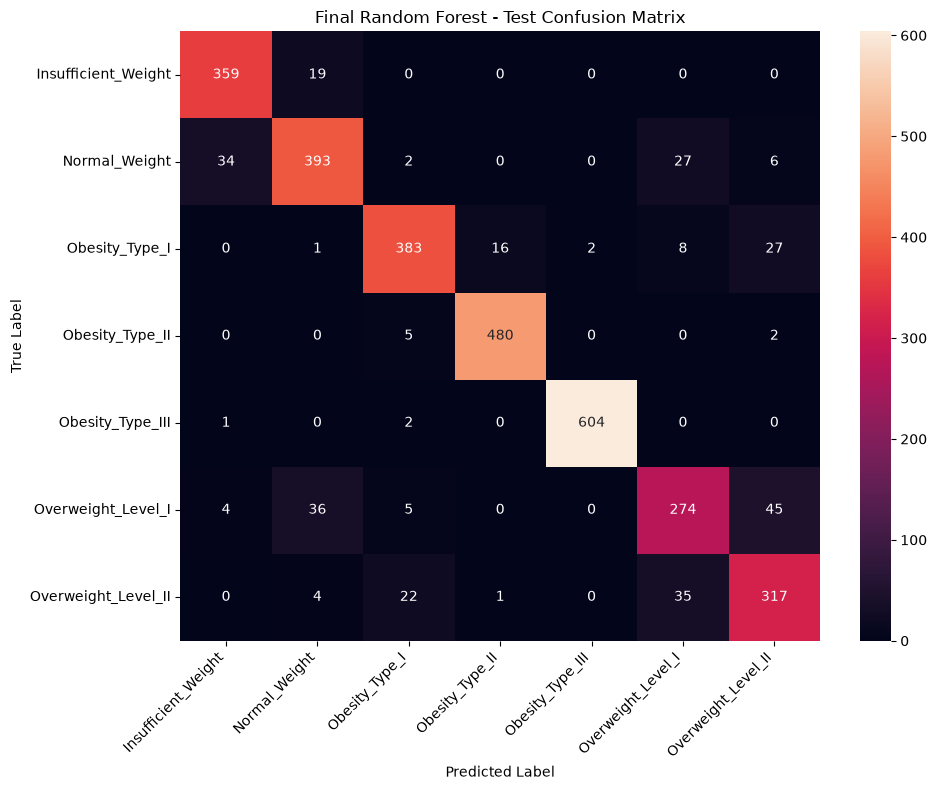

In [63]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

final_cm = confusion_matrix(
    y_test,
    final_test_pred,
    labels=class_names
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final Random Forest - Test Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [64]:
final_cm_df = pd.DataFrame(
    final_cm,
    index=class_names,
    columns=class_names
)

final_cm_df.to_csv(
    "../reports/generated/final_confusion_matrix.csv"
)

print("Saved:", "../reports/generated/final_confusion_matrix.csv")

Saved: ../reports/generated/final_confusion_matrix.csv


## Saving the Final Model

The final selected Random Forest pipeline is saved as a Joblib artifact.

The saved pipeline contains the preprocessing steps and trained classifier, allowing the same transformations and model to be reused for future predictions.

In [65]:
import joblib
from pathlib import Path

model_dir = Path("../models/staging")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "obesity_risk_pipeline.joblib"

joblib.dump(final_model, model_path)

print("Saved:", model_path)

Saved: ../models/staging/obesity_risk_pipeline.joblib


In [66]:
print("Model file exists:", model_path.exists())
print("Model size (MB):", round(model_path.stat().st_size / (1024 * 1024), 2))

Model file exists: True
Model size (MB): 29.53


## Final Model Metadata

Metadata is stored alongside the final model to document the selected configuration, validation performance, final test performance, dataset sizes, classes, and reproducibility settings.

In [67]:
import json
import sklearn

metadata = {
    "project": "Obesity Risk Intelligence System",
    "model": "Random Forest - Tuned",
    "selection_metric": "Macro F1",
    
    "best_hyperparameters": rf_search.best_params_,
    
    "validation_metrics": {
        "Accuracy": float(rf_tuned_metrics["Accuracy"]),
        "Balanced Accuracy": float(rf_tuned_metrics["Balanced Accuracy"]),
        "Macro F1": float(rf_tuned_metrics["Macro F1"]),
        "Weighted F1": float(rf_tuned_metrics["Weighted F1"])
    },
    
    "final_test_metrics": {
        "Accuracy": float(final_test_metrics["Accuracy"]),
        "Balanced Accuracy": float(final_test_metrics["Balanced Accuracy"]),
        "Macro F1": float(final_test_metrics["Macro F1"]),
        "Weighted F1": float(final_test_metrics["Weighted F1"])
    },
    
    "dataset": {
        "training_samples": int(len(X_train)),
        "validation_samples": int(len(X_val)),
        "development_samples": int(len(X_dev)),
        "test_samples": int(len(X_test)),
        "raw_features": int(X_train.shape[1]),
        "transformed_features": int(final_model.named_steps["preprocessor"].transform(X_train).shape[1]),
        "classes": list(class_names)
    },
    
    "reproducibility": {
        "random_seed": 42,
        "cross_validation_folds": 5,
        "tuning_candidates": 20,
        "sklearn_version": sklearn.__version__
    }
}

metadata_path = Path("../models/staging/model_metadata.json")

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:", metadata_path)

Saved: ../models/staging/model_metadata.json


In [68]:
print("Metadata file exists:", metadata_path.exists())

with open(metadata_path, "r") as f:
    saved_metadata = json.load(f)

print("Model:", saved_metadata["model"])
print("Selection metric:", saved_metadata["selection_metric"])
print("Test Macro F1:", saved_metadata["final_test_metrics"]["Macro F1"])

Metadata file exists: True
Model: Random Forest - Tuned
Selection metric: Macro F1
Test Macro F1: 0.8916633273935437
